**Experiment Title**: To implement data preparation and cleaning using Python
Programming

In [39]:
import pandas as pd
import numpy as np

In [40]:
df = pd.read_csv(r'/content/retail_store_sales.csv')

In [41]:
print(df.head())

  Transaction ID Customer ID       Category          Item  Price Per Unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   

   Quantity  Total Spent  Payment Method Location Transaction Date  \
0      10.0        185.0  Digital Wallet   Online       2024-04-08   
1       9.0        261.0  Digital Wallet   Online       2023-07-23   
2       2.0         43.0     Credit Card   Online       2022-10-05   
3       9.0        247.5     Credit Card   Online       2022-05-07   
4       7.0         87.5  Digital Wallet   Online       2022-10-02   

  Discount Applied  
0             True  
1             True  
2            False  
3              NaN  
4          

In [42]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB
None


In [43]:
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].mean())

In [44]:
df.drop_duplicates(inplace=True)

In [45]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

In [46]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

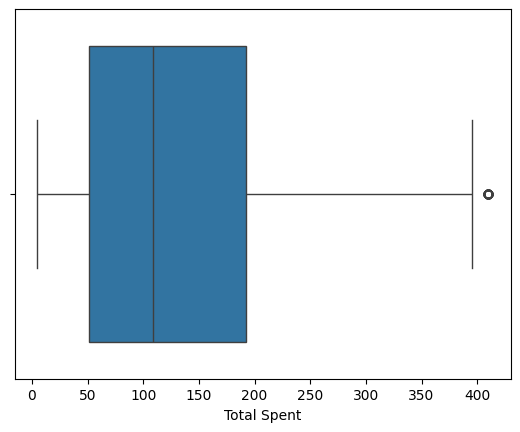

In [48]:
sns.boxplot(x=df['Total Spent'])
plt.show()

In [49]:
df = pd.get_dummies(df, columns=['Category'], drop_first=True)

In [50]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['encoded_payment_method'] = le.fit_transform(df['Payment Method'])

In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['Price Per Unit', 'Total Spent']] = scaler.fit_transform(df[['Price Per Unit', 'Total Spent']])

In [52]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['Price Per Unit', 'Total Spent']] = scaler.fit_transform(df[['Price Per Unit', 'Total Spent']])

In [53]:
import numpy as np
df['Category_Furniture'] = np.log1p(df['Category_Furniture'])

In [54]:
print(df.isnull().sum())

Transaction ID                                    0
Customer ID                                       0
Item                                           1213
Price Per Unit                                    0
Quantity                                        604
Total Spent                                     604
Payment Method                                    0
Location                                          0
Transaction Date                                  0
Discount Applied                               4199
Category_Butchers                                 0
Category_Computers and electric accessories       0
Category_Electric household essentials            0
Category_Food                                     0
Category_Furniture                                0
Category_Milk Products                            0
Category_Patisserie                               0
encoded_payment_method                            0
dtype: int64


In [55]:
print(df.dtypes)

Transaction ID                                         object
Customer ID                                            object
Item                                                   object
Price Per Unit                                        float64
Quantity                                              float64
Total Spent                                           float64
Payment Method                                         object
Location                                               object
Transaction Date                               datetime64[ns]
Discount Applied                                       object
Category_Butchers                                        bool
Category_Computers and electric accessories              bool
Category_Electric household essentials                   bool
Category_Food                                            bool
Category_Furniture                                    float16
Category_Milk Products                                   bool
Category

In [56]:
print(df.shape)

(12575, 18)


In [57]:
df.to_csv('cleaned_data.csv', index=False)